# **4️⃣ Classification**

- Decision Tree
- Random Forest
- Gradient Boosting Trees
- XGBoost

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

In [2]:
# Load dataset
df=pd.read_csv('../dataset/EDA_and_Cleaning.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1.0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34.0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,45.0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
3,1,0,0,1,22.0,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1949.40,0
4,0,0,0,0,10.0,0,1,0,2,0,0,0,0,0,0,0,3,29.75,301.90,0


In [3]:
X=df.drop('Churn', axis=1)
y=df['Churn']

## Evaluate Model

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Model dictionary
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results
results = []
all_roc_curves = {}

def eval_metric(model, X_train, y_train, X_test, y_test):
    """Evaluate metrics for the train and test set."""
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

def evaluate_model(model_name, model, X, y):
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    specificity_scores = []
    f1_scores = []
    roc_auc_scores = []
    confusion_matrices = []
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        print(f"{model_name}: fold {fold+1}...")

        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Scale data
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train model
        model.fit(X_train_scaled, y_train)

        # Evaluate model using eval_metric
        eval_metric(model, X_train_scaled, y_train, X_test_scaled, y_test)

        # Predict
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        # Store metrics
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))
        specificity_scores.append(specificity)
        f1_scores.append(f1_score(y_test, y_pred))
        roc_auc_scores.append(roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0)
        confusion_matrices.append(confusion_matrix(y_test, y_pred))

        # ROC Curve
        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    all_roc_curves[model_name] = (mean_fpr, mean_tpr, np.mean(roc_auc_scores))

    # Return evaluation results
    return {
        'model': model_name,
        'accuracy_score': np.mean(accuracy_scores),
        'precision_score': np.mean(precision_scores),
        'recall': np.mean(recall_scores),
        'specificity': np.mean(specificity_scores),
        'f1_score': np.mean(f1_scores),
        'roc_auc': np.mean(roc_auc_scores),
        'confusion_matrix': np.mean(confusion_matrices, axis=0)
    }

# Evaluate all models
overall_results = []
for model_name, model in models.items():
    result = evaluate_model(model_name, model, X, y)
    overall_results.append(result)

# Convert results to DataFrame
results_df = pd.DataFrame(overall_results)

# Display results with color gradient
results_df.sort_values(by='roc_auc', ascending=False).style.background_gradient(cmap='YlGn')


DecisionTree: fold 1...
Test_Set
[[871 164]
 [162 212]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.56      0.57      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409


Train_Set
[[4137    2]
 [  10 1485]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       1.00      0.99      1.00      1495

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634

DecisionTree: fold 2...
Test_Set
[[842 193]
 [157 217]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1035
           1       0.53      0.58      0.55       374

    accuracy                    

,model,accuracy_score,precision_score,recall,specificity,f1_score,roc_auc,confusion_matrix
2,GradientBoosting,0.819394,0.690269,0.579453,0.906070,0.629862,0.875781,[[937.6 97.2] [157.2 216.6]]
3,XGBoost,0.800509,0.640837,0.564987,0.885583,0.600403,0.854337,[[916.4 118.4] [162.6 211.2]]
1,RandomForest,0.804911,0.661123,0.543059,0.899499,0.595887,0.852551,[[930.8 104. ] [170.8 203. ]]
0,DecisionTree,0.753229,0.534189,0.551621,0.826055,0.542523,0.689543,[[854.8 180. ] [167.6 206.2]]


## **Model Interpretation**


Cross-validation accuracy: 0.8191 ± 0.0049
Feature Importance:
             Feature  Importance
14          Contract    0.365397
18      TotalCharges    0.201611
4             tenure    0.135907
17    MonthlyCharges    0.120006
8     OnlineSecurity    0.062784
11       TechSupport    0.047655
15  PaperlessBilling    0.016737
16     PaymentMethod    0.012666
6      MultipleLines    0.009866
1      SeniorCitizen    0.009067
7    InternetService    0.005601
9       OnlineBackup    0.003448
13   StreamingMovies    0.002369
3         Dependents    0.002239
12       StreamingTV    0.001772
5       PhoneService    0.001145
0             gender    0.000936
2            Partner    0.000512
10  DeviceProtection    0.000282

SHAP Interpretation (Global):


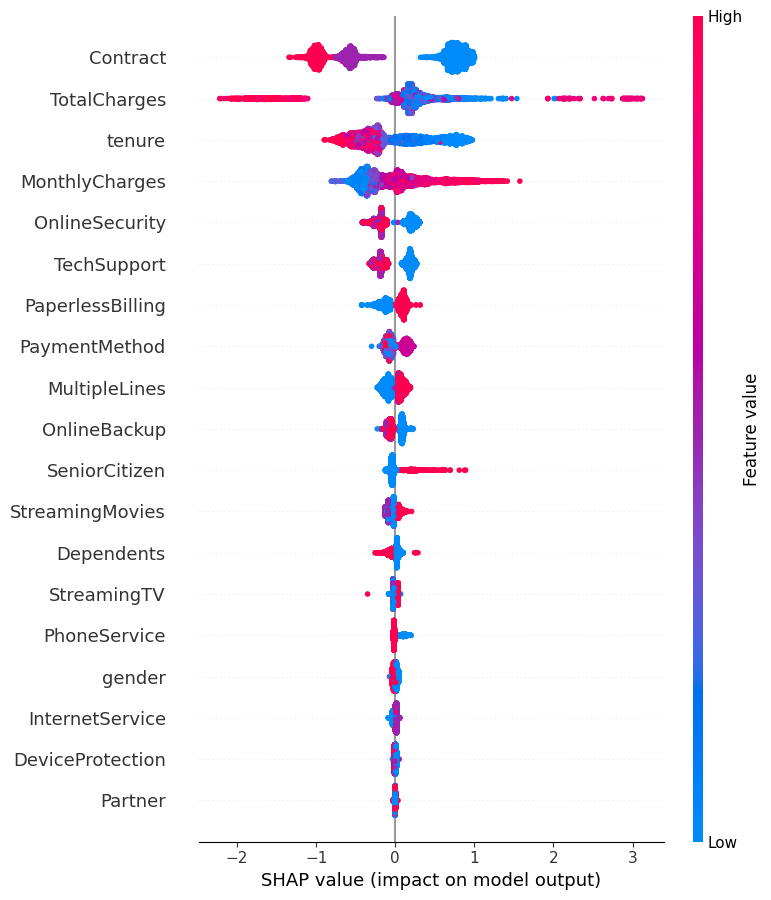

In [5]:
import shap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Feature Importance
def interpret_feature_importance(model, X_resampled, y_resampled):
    model.fit(X_resampled, y_resampled)
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X_resampled.columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    print("Feature Importance:")
    print(feature_importance)
    return feature_importance

# SHAP Global Interpretation
def interpret_with_shap(model, X_resampled, feature_names):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_resampled)

    print("\nSHAP Interpretation (Global):")
    shap.summary_plot(shap_values, X_resampled, feature_names=feature_names)

# Overall Interpretation
def interpret_model(model, X, y, cv_folds=5):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train model
        model.fit(X_train, y_train)

        # Save score
        score = model.score(X_test, y_test)
        scores.append(score)

    print(f"\nCross-validation accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    interpret_feature_importance(model, X_train, y_train)
    interpret_with_shap(model, X_train.values, X.columns)

# Run interpretation
gb = GradientBoostingClassifier(random_state=42)
interpret_model(gb, X, y, cv_folds=5)


## Save Model

In [7]:
import joblib
joblib.dump(gb, '../model/churn_prediction_model.pkl')

['../model/churn_prediction_model.pkl']

---------